In [2]:
import sys
from pathlib import Path

current = Path().absolute().parent
sys.path.insert(0, (current / "src").as_posix())
from data_profiling import ProfileReport
import pandas as pd
import loaders
import preprocessing as pp

In [ ]:
df = loaders.load_combined()
df = pp.apply_date_hygiene(df)  # composite-key (group, anonyme) date hygiene
df = pp.add_derived(df)  # lesion_pf/ft, female, deltas, worsened_pf, ...
wide = pp.to_wide(df)  # one row per patient (group, anonyme)*
profile = ProfileReport(wide, title="Profiling Report")

In [4]:
df = df.rename(
    columns=lambda x: x.rstrip().replace(" / ", "_").replace(" ", "_").lower()
)

In [5]:
df.columns

Index(['anonyme', 'sexe', 'date_de_naissance', 'taille', 'poids', 'imc',
       'sport', 'pivot_pivot_contact', 'travail', 'travail_physique', 'tabac',
       'date_du_trauma', 'date_chir', 'trochlée', 'rotule', 'pte', 'pti',
       'cfe', 'cfi', 'group', 'lesion_total', 'lesion_total_strict',
       'lesion_total_permissive', 'n_sites_observed', 'lesion_any',
       'lesion_pf', 'lesion_ft', 'female', 'surgery_num', 'time',
       'age_at_trauma', 'age_at_surgery', 'trauma_to_surgery_d'],
      dtype='object')

In [6]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 53/53 [00:00<00:00, 227.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Nice plots

In [7]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import altair as alt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.mosaicplot import mosaic
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.descriptivestats import sign_test
import pingouin as pg
import scikit_posthocs as sp
import pymc as pm
import arviz as az
from lifelines import WeibullAFTFitter

try:
    import ptitprince as pt

    HAS_PTITPRINCE = True
except Exception:
    HAS_PTITPRINCE = False

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
sns.set_theme(style="whitegrid", context="notebook")

RNG = np.random.default_rng(2026)
print("Configuration OK  pymc", pm.__version__, "| arviz", az.__version__)


g++ not available, if using conda: `conda install gxx`


Configuration OK  pymc 6.0.1 | arviz 1.1.0


## 0  Configuration & variables dérivées

### 0a Nettoyage des données

Les lignes 35/37/31 présentent des décalages de 1 jour sur `date_de_naissance` / `date_du_trauma` entre les deux lignes appariées d'un même patient (probablement des coquilles de saisie). On canonicalise par `anonyme` en gardant la date la plus précoce.


In [ ]:
# Canonicalisation des dates par patient (corrige les décalages de 1 jour entre lignes appariées)
df["date_de_naissance"] = df.groupby("anonyme")["date_de_naissance"].transform("min")
df["date_du_trauma"] = df.groupby("anonyme")["date_du_trauma"].transform("min")

assert df.shape[0] == 38, f"expected 38 lignes, got {df.shape[0]}"
print("Nettoyage OK  19 patients × 2 événements =", df.shape[0], "lignes")


Hygiene OK  19 patients × 2 events = 38 rows


### 0b Variables dérivées

Variables de cycle de vie par ligne + agrégats lésionnels, puis pivot large (19 patients) pour les Δ appariés et table statique `patient`.


In [74]:
LESION_SITES = ["trochlée", "rotule", "pte", "pti", "cfe", "cfi"]

# --- variables dérivées par ligne ---
df["age_at_trauma"] = (df["date_du_trauma"] - df["date_de_naissance"]).dt.days / 365.25
df["age_at_surgery"] = (df["date_chir"] - df["date_de_naissance"]).dt.days / 365.25
df["trauma_to_surgery_d"] = (df["date_chir"] - df["date_du_trauma"]).dt.days
df["lesion_total"] = df[LESION_SITES].sum(axis=1)
df["n_sites_affected"] = (df[LESION_SITES] > 0).sum(axis=1)
df["lesion_any"] = df["lesion_total"] > 0

# Ordre chirurgical : 1 = date_chir la plus ancienne, 2 = la plus récente
df["surgery_num"] = df.groupby("anonyme")["date_chir"].rank(method="first").astype(int)

# --- pivot large pour l'analyse appariée des Δ ---
piv = df.pivot_table(
    index="anonyme",
    columns="surgery_num",
    values=LESION_SITES + ["lesion_total", "n_sites_affected", "date_chir"],
    aggfunc="first",
)
piv.columns = [f"{a}_s{b}" for a, b in piv.columns]
wide = piv.copy()
for site in LESION_SITES + ["lesion_total", "n_sites_affected"]:
    wide[f"delta_{site}"] = wide[f"{site}_s2"] - wide[f"{site}_s1"]
wide["inter_surgery_d"] = (wide["date_chir_s2"] - wide["date_chir_s1"]).dt.days

# --- table patient (1 ligne par anonyme, attributs statiques) ---
patient = (
    df
    .drop_duplicates("anonyme")[
        [
            "anonyme",
            "sexe",
            "imc",
            "taille",
            "poids",
            "pivot_pivot_contact",
            "travail_physique",
            "tabac",
            "age_at_trauma",
            "sport",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

patient["bmi_class"] = pd.cut(
    patient["imc"],
    [0, 18.5, 25, 30, 99],
    labels=["maigreur", "normal", "surpoids", "obèse"],
)
patient["pivot_tier_lbl"] = patient["pivot_pivot_contact"].map({
    0: "pivot faible",
    1: "pivot sans contact",
    2: "pivot avec contact",
})
patient["sex_lbl"] = patient["sexe"].map({1: "M", 2: "F"})

# Contrôles de cohérence
assert wide.shape[0] == 19
assert patient.shape[0] == 19
assert df["surgery_num"].value_counts().to_dict() == {1: 19, 2: 19}

print(
    "Variables dérivées OK  long :",
    df.shape,
    "| large :",
    wide.shape,
    "| patient :",
    patient.shape,
)
patient.head()


Variables dérivées OK  long : (38, 26) | large : (19, 27) | patient : (19, 13)


,anonyme,sexe,imc,taille,poids,pivot_pivot_contact,travail_physique,tabac,age_at_trauma,sport,bmi_class,pivot_tier_lbl,sex_lbl
0,1,1,24.983563,1.95,95,2,0,0,17.571526,Foot +,normal,pivot avec contact,M
1,2,1,25.503616,1.76,79,1,1,0,21.615332,Ski ++,surpoids,pivot sans contact,M
2,3,1,30.470522,1.68,86,2,0,1,20.429843,Rugby +,obèse,pivot avec contact,M
3,4,2,23.046875,1.60,59,1,1,0,26.078029,Ski ++,normal,pivot sans contact,F
4,5,1,24.691358,1.80,80,2,1,0,30.236824,Boxe tai,normal,pivot avec contact,M


### 0c Palettes & style

- `cividis`  sévérité lésionnelle ordinale (sûr pour le daltonisme, 0→2)
- `magma_r`  catégorie de pivot (0→2)
- `Set2`     sexe (qualitatif)
- `RdBu_r`   divergent pour les scores Δ


In [75]:
PAL_LESION = "cividis"
PAL_TIER = "magma_r"
PAL_SEX = {"M": "#66c2a5", "F": "#fc8d62"}
PAL_DELTA = "RdBu_r"

PIVOT_ORDER = ["pivot faible", "pivot sans contact", "pivot avec contact"]
PIVOT_COLOR = dict(zip(PIVOT_ORDER, sns.color_palette(PAL_TIER, 3).as_hex()))

# Thème plotly
import plotly.io as pio

pio.templates.default = "plotly_white"

print("Style OK")


Style OK


## 1  Profil démographique & morphologique

Qui sont les 19 patients ? Répartition par sexe, âge au traumatisme, morphologie (taille × poids × IMC), pratique sportive.


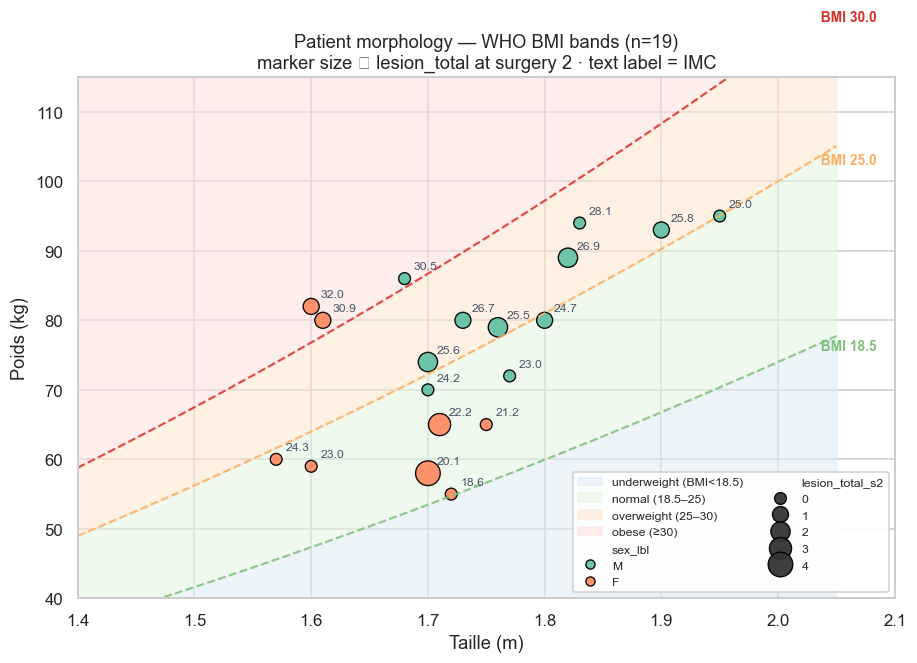

In [ ]:
# Fig 1  Morphologie des patients with WHO BMI iso-curves
# (KDE on n=19 is just bandwidth smoothing; encoding IMC as marker size duplicates
#  what taille×poids already shows  IMC = poids / taille². Instead overlay BMI
#  iso-lines so the clinician sees the WHO thresholds directly.)

import numpy as np

# Use lesion_total at S2 for marker size (independent, clinically informative)
plot_df = (
    patient.merge(
        risk_df[["anonyme", "lesion_total_s2"]],
        on="anonyme",
        how="left",
    )
    if "risk_df" in dir()
    else patient.assign(lesion_total_s2=0)
)

fig, ax = plt.subplots(figsize=(8.5, 6.2))

# BMI iso-curves: poids = BMI * taille^2, drawn over plotting range
x_grid = np.linspace(1.40, 2.05, 200)
WHO = [
    (18.5, "normal lower", "#7fbf7b"),
    (25.0, "overweight", "#fdae61"),
    (30.0, "obese", "#d73027"),
]
# Light shading between iso-lines (under/normal/over/obese bands)
y_lo = 18.5 * x_grid**2
y_med = 25.0 * x_grid**2
y_hi = 30.0 * x_grid**2
ax.fill_between(
    x_grid, 0, y_lo, color="#deebf7", alpha=0.55, label="underweight (BMI<18.5)"
)
ax.fill_between(
    x_grid, y_lo, y_med, color="#e5f5e0", alpha=0.55, label="normal (18.5–25)"
)
ax.fill_between(
    x_grid, y_med, y_hi, color="#fee6ce", alpha=0.55, label="overweight (25–30)"
)
ax.fill_between(x_grid, y_hi, 130, color="#fde0dd", alpha=0.55, label="obese (≥30)")

for bmi, lbl, col in WHO:
    y = bmi * x_grid**2
    ax.plot(x_grid, y, "--", lw=1.4, color=col, alpha=0.85)
    # label on right edge
    ax.text(
        2.03,
        bmi * 2.03**2,
        f"  BMI {bmi}",
        color=col,
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# Scatter  size = lesion_total_s2 (0–12), color = sexe
sns.scatterplot(
    data=plot_df,
    x="taille",
    y="poids",
    hue="sex_lbl",
    size="lesion_total_s2",
    sizes=(60, 360),
    size_norm=(0, 6),
    palette=PAL_SEX,
    edgecolor="black",
    linewidth=0.9,
    alpha=0.95,
    ax=ax,
)

# Annotate the BMI of each point in small text next to marker
for _, r in plot_df.iterrows():
    ax.annotate(
        f"{r['imc']:.1f}",
        (r["taille"], r["poids"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="#475569",
    )

ax.set_xlim(1.40, 2.10)
ax.set_ylim(40, 115)
ax.set_title(
    "Morphologie des patients  bandes OMS d'IMC (n=19)\ntaille des marqueurs ∝ score lésionnel total à la chirurgie 2 · étiquette = IMC"
)
ax.set_xlabel("Taille (m)")
ax.set_ylabel("Poids (kg)")
ax.legend(loc="lower right", fontsize=8, framealpha=0.92, ncols=2)
plt.tight_layout()
plt.show()

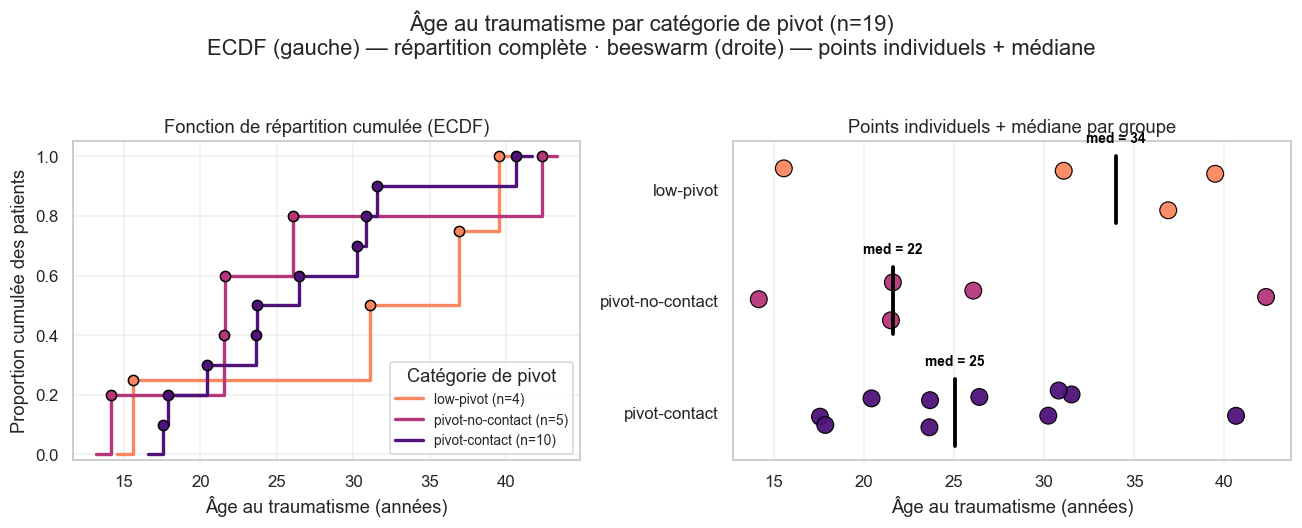

In [69]:
# Fig 2  Âge au traumatisme par catégorie de pivot (ECDF + beeswarm + médiane)
# (Le KDE échoue ici : 4-8 patients par groupe, variance faible → courbes plates.
#  ECDF + points individuels + ligne de médiane est plus honnête à ce n.)

patient_plot = patient.copy()
patient_plot["pivot_tier_lbl"] = pd.Categorical(
    patient_plot["pivot_tier_lbl"],
    categories=PIVOT_ORDER,
    ordered=True,
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.1]}
)

# --- LEFT : ECDF par tier ---
ax = axes[0]
for tier in PIVOT_ORDER:
    sub = patient_plot.loc[
        patient_plot["pivot_tier_lbl"] == tier, "age_at_trauma"
    ].sort_values()
    if len(sub) == 0:
        continue
    x = np.r_[sub.min() - 1, sub.values, sub.max() + 1]
    y = np.r_[0, np.arange(1, len(sub) + 1) / len(sub), 1.0]
    ax.step(
        x,
        y,
        where="post",
        color=PIVOT_COLOR[tier],
        lw=2.2,
        label=f"{tier} (n={len(sub)})",
    )
    ax.scatter(
        sub.values,
        np.arange(1, len(sub) + 1) / len(sub),
        color=PIVOT_COLOR[tier],
        edgecolor="black",
        s=45,
        zorder=3,
    )
ax.set_title("Fonction de répartition cumulée (ECDF)")
ax.set_xlabel("Âge au traumatisme (années)")
ax.set_ylabel("Proportion cumulée des patients")
ax.set_ylim(-0.02, 1.05)
ax.legend(title="Catégorie de pivot", loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# --- RIGHT : beeswarm + médiane par tier ---
ax = axes[1]
sns.stripplot(
    data=patient_plot,
    y="pivot_tier_lbl",
    x="age_at_trauma",
    order=PIVOT_ORDER,
    palette=PIVOT_COLOR,
    size=11,
    edgecolor="black",
    linewidth=0.8,
    jitter=0.20,
    alpha=0.95,
    ax=ax,
)
# Médiane par tier (ligne verticale courte)
for i, tier in enumerate(PIVOT_ORDER):
    vals = patient_plot.loc[patient_plot["pivot_tier_lbl"] == tier, "age_at_trauma"]
    if len(vals) == 0:
        continue
    med = vals.median()
    ax.plot([med, med], [i - 0.3, i + 0.3], color="black", lw=2.5, zorder=4)
    ax.annotate(
        f"med = {med:.0f}",
        (med, i - 0.42),
        ha="center",
        fontsize=9,
        color="black",
        fontweight="bold",
    )
ax.set_title("Points individuels + médiane par groupe")
ax.set_xlabel("Âge au traumatisme (années)")
ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.3)

plt.suptitle(
    "Âge au traumatisme par catégorie de pivot (n=19)\n"
    "ECDF (gauche)  répartition complète · beeswarm (droite)  points individuels + médiane",
    y=1.04,
)
plt.tight_layout()
plt.show()


In [70]:
# Fig 10  Pyramide des âges par sexe, empilée par catégorie de pivot
patient_plot = patient.copy()
patient_plot["age_bin"] = pd.cut(
    patient_plot["age_at_trauma"],
    bins=[10, 20, 30, 40, 50, 60],
    labels=["10-19", "20-29", "30-39", "40-49", "50-59"],
)

pyramid = (
    patient_plot
    .groupby(["age_bin", "sex_lbl", "pivot_tier_lbl"], observed=True)
    .size()
    .reset_index(name="n")
)
pyramid["signed_n"] = np.where(pyramid["sex_lbl"] == "M", -pyramid["n"], pyramid["n"])

fig = go.Figure()
for tier in PIVOT_ORDER:
    sub = pyramid[pyramid["pivot_tier_lbl"] == tier]
    for sex in ["M", "F"]:
        s = sub[sub["sex_lbl"] == sex]
        fig.add_bar(
            y=s["age_bin"],
            x=s["signed_n"],
            orientation="h",
            name=f"{sex} · {tier}",
            marker_color=PIVOT_COLOR[tier],
            marker_pattern_shape="" if sex == "F" else "/",
            customdata=np.abs(s["signed_n"]),
            hovertemplate="%{y} · "
            + sex
            + " · "
            + tier
            + ": %{customdata}<extra></extra>",
        )

fig.update_layout(
    barmode="relative",
    title="Pyramide des âges par sexe  couleur = catégorie de pivot (Hommes à gauche, Femmes à droite, n=19)",
    xaxis=dict(
        title="Count",
        tickvals=[-3, -2, -1, 0, 1, 2, 3],
        ticktext=["3", "2", "1", "0", "1", "2", "3"],
    ),
    yaxis_title="Tranche d'âge (années)",
    height=420,
    legend=dict(orientation="h", y=-0.2),
)
fig.show()


In [ ]:
# Stats §1.1  Sex comparison on age/imc/taille/poids: Mann-Whitney + bootstrap BCa CI
def boot_median_ci(x, n_boot=4000, ci=0.95):
    arr = np.asarray(x)
    arr = arr[~np.isnan(arr)]
    res = stats.bootstrap(
        (arr,),
        np.median,
        n_resamples=n_boot,
        confidence_level=ci,
        method="BCa",
        random_state=RNG,
    )
    return np.median(arr), res.confidence_interval.low, res.confidence_interval.high


lignes = []
for col in ["age_at_trauma", "imc", "taille", "poids"]:
    m = patient.loc[patient["sex_lbl"] == "M", col].dropna()
    f = patient.loc[patient["sex_lbl"] == "F", col].dropna()
    U, p = stats.mannwhitneyu(m, f, alternative="two-sided")
    n1, n2 = len(m), len(f)
    rank_biserial = 1 - 2 * U / (n1 * n2)  # Wendt formulation
    med_m, lo_m, hi_m = boot_median_ci(m)
    med_f, lo_f, hi_f = boot_median_ci(f)
    lignes.append({
        "variable": col,
        "median_M": f"{med_m:.2f} [{lo_m:.2f}, {hi_m:.2f}]",
        "median_F": f"{med_f:.2f} [{lo_f:.2f}, {hi_f:.2f}]",
        "U": U,
        "p": round(p, 4),
        "rank_biserial_r": round(rank_biserial, 3),
    })

print("Comparaison par sexe (Mann-Whitney U + IC BCa bootstrap de la médiane)")
pd.DataFrame(lignes)


In [ ]:
# Stats §1.2  Prévalence des classes IMC OMS via Dirichlet-multinomial bayésien
bmi_counts = (
    patient["bmi_class"]
    .value_counts()
    .reindex(["maigreur", "normal", "surpoids", "obèse"], fill_value=0)
    .astype(int)
)
print("Effectifs observés :\n", bmi_counts.to_dict())

with pm.Model() as bmi_model:
    theta = pm.Dirichlet("theta", a=np.ones(4))
    y = pm.Multinomial(
        "y", n=int(bmi_counts.sum()), p=theta, observed=bmi_counts.values
    )
    idata_bmi = pm.sample(
        2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        progressbar=False,
        random_seed=2026,
    )

summary = az.summary(idata_bmi, ci_prob=0.94, ci_kind="hdi")
summary.index = [f"theta[{c}]" for c in ["maigreur", "normal", "surpoids", "obèse"]]
print("\nPrévalence postérieure des classes IMC (Dirichlet-multinomial, α=1)")
summary[["mean", "hdi_3%", "hdi_97%"]]


In [ ]:
# Stats §1.3  Prévalence par catégorie de pivot via Beta-binomial bayésien
tier_counts = (
    patient["pivot_tier_lbl"]
    .value_counts()
    .reindex(PIVOT_ORDER, fill_value=0)
    .astype(int)
)
N = int(tier_counts.sum())
print("Effectifs par catégorie de pivot :\n", tier_counts.to_dict(), "| N =", N)

posteriors = {}
for tier, k in tier_counts.items():
    with pm.Model():
        p = pm.Beta("p", alpha=1, beta=1)
        y = pm.Binomial("y", n=N, p=p, observed=int(k))
        idata = pm.sample(
            1500,
            tune=1000,
            chains=4,
            target_accept=0.95,
            progressbar=False,
            random_seed=2026,
        )
    posteriors[tier] = az.summary(idata, ci_prob=0.94, ci_kind="hdi").loc["p"]

print("\nP(catégorie de pivot) postérieure  a priori Beta(1,1)")
pd.DataFrame(posteriors).T[["mean", "hdi_3%", "hdi_97%"]]


## 2  Associations aux facteurs de risque

Analyse transversale à la **chirurgie 1** : la morphologie, la catégorie de pivot du sport, le mode de vie (tabac, travail physique) ou le sexe prédisent-ils la charge lésionnelle ?


In [73]:
df.columns

Index(['anonyme', 'sexe', 'date_de_naissance', 'taille', 'poids', 'imc',
       'sport', 'pivot_pivot_contact', 'travail', 'travail_physique', 'tabac',
       'date_du_trauma', 'date_chir', 'trochlée', 'rotule', 'pte', 'pti',
       'cfe', 'cfi'],
      dtype='object')

In [76]:
# Trame d'analyse des facteurs de risque (1 ligne par patient, données lésionnelles à C1)
s1 = df[df["surgery_num"] == 1].set_index("anonyme")
risk_df = (
    patient
    .set_index("anonyme")
    .join(
        s1[
            LESION_SITES + ["lesion_total", "n_sites_affected", "lesion_any"]
        ].add_suffix("_s1")
    )
    .reset_index()
)

# Aussi à C2 (utilisé par Fig 13 + modèles ordinaux)
s2 = df[df["surgery_num"] == 2].set_index("anonyme")
risk_df = risk_df.join(
    s2[["lesion_total", "n_sites_affected", "lesion_any"]].add_suffix("_s2"),
    on="anonyme",
)
risk_df.head()


,anonyme,sexe,imc,taille,poids,pivot_pivot_contact,travail_physique,tabac,age_at_trauma,sport,...,pte_s1,pti_s1,cfe_s1,cfi_s1,lesion_total_s1,n_sites_affected_s1,lesion_any_s1,lesion_total_s2,n_sites_affected_s2,lesion_any_s2
0,1,1,24.983563,1.95,95,2,0,0,17.571526,Foot +,...,0,0,0,0,0,0,False,0,0,False
1,2,1,25.503616,1.76,79,1,1,0,21.615332,Ski ++,...,0,0,0,0,0,0,False,2,2,True
2,3,1,30.470522,1.68,86,2,0,1,20.429843,Rugby +,...,0,0,0,0,0,0,False,0,0,False
3,4,2,23.046875,1.60,59,1,1,0,26.078029,Ski ++,...,0,0,0,0,0,0,False,0,0,False
4,5,1,24.691358,1.80,80,2,1,0,30.236824,Boxe tai,...,0,0,0,0,0,0,False,1,1,True


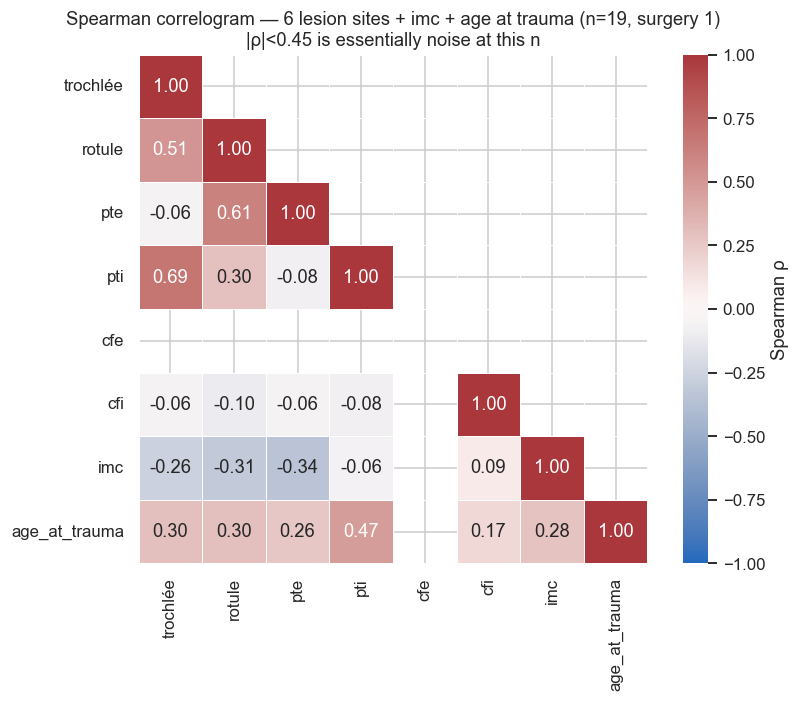

In [77]:
# Fig 3  Corrélogramme de Spearman (6 compartiments + IMC + âge)
corr_cols = [f"{s}_s1" for s in LESION_SITES] + ["imc", "age_at_trauma"]
cm = risk_df[corr_cols].rename(columns={f"{s}_s1": s for s in LESION_SITES})
rho = cm.corr(method="spearman")

mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    rho,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Spearman ρ"},
    ax=ax,
)
ax.set_title(
    "Spearman correlogram  6 lesion sites + imc + age at trauma (n=19, surgery 1)\n|ρ|<0.45 is essentially noise at this n"
)
plt.tight_layout()
plt.show()


C2 = Chirurgie 2 (deuxième intervention).Lescore lésionnel total à C2=sommedesscoresdes6compartiments
cartilagineuxdugenouévaluéslorsdela2ᵉchirurgie.

Formule(cellule10,dérivation):
  - LESION_SITES = ["trochlée", "rotule", "pte", "pti", "cfe", "cfi"]
  - df["lesion_total"] = df[LESION_SITES].sum(axis=1)

Puis dans le pivot large : lesion_total_s2 = lesion_total quand surgery_num == 2.

Les 6 compartiments (zones anatomiques cartilagineuses du genou) :


  ┌──────────┬─────────────────────────┬──────────────────────────────────────┐
  │   Code   │      Compartiment       │             Localisation             │
  ├──────────┼─────────────────────────┼──────────────────────────────────────┤
  │ Trochlée │ Cartilage trochléen     │ Gorge fémorale où coulisse la rotule │
  ├──────────┼─────────────────────────┼──────────────────────────────────────┤
  │ Rotule   │ Cartilage rotulien      │ Face postérieure de la patella       │
  ├──────────┼─────────────────────────┼──────────────────────────────────────┤
  │ PTE      │ Plateau Tibial Externe  │ Plateau latéral du tibia             │
  ├──────────┼─────────────────────────┼──────────────────────────────────────┤
  │ PTI      │ Plateau Tibial Interne  │ Plateau médial du tibia              │
  ├──────────┼─────────────────────────┼──────────────────────────────────────┤
  │ CFE      │ Condyle Fémoral Externe │ Condyle latéral du fémur             │
  ├──────────┼─────────────────────────┼──────────────────────────────────────┤
  │ CFI      │ Condyle Fémoral Interne │ Condyle médial du fémur              │
  └──────────┴─────────────────────────┴──────────────────────────────────────┘

Échelle par compartiment : 0/1/2 ordinal (probablement adapté d'Outerbridge/ICRS) :
  - 0  cartilage intact, pas de lésion
  - 1  lésion partielle (fissure, ramollissement, perte d'épaisseur)
  - 2  lésion profonde (pleine épaisseur, os exposé)

Plage du score total : 0 (aucune lésion) → 12 (toutes les zones en grade 2).

Exemple patient 18 (cellule 10) à C2 :
  - Trochlée=0, Rotule=2, PTE=1, PTI=1, CFE=0, CFI=0 → lesion_total_s2 = 4

Limite : c'est un score sommé non pondéré  il ne distingue pas un patient avec 4 compartiments en grade 1
(score=4) d'un patient avec 2 compartiments en grade 2 (score aussi=4). Pour ça, la colonne n_sites_affected
(nombre de compartiments touchés) complète la lecture, et le modèle ordinal hiérarchique §3.4 analyse chaque
compartiment séparément en gardant l'info ordinale par site.

In [8]:
# Fig 9  Matrice de profil de risque par patient
# (Dotplot de Cleveland confondait les encodages tabac/travail_physique.
#  Ici : patients en lignes (triés par charge lésionnelle à C2),
#  colonnes = variables de risque + barre IMC + barre score lésionnel.)

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

prof = risk_df.copy()
prof = prof.sort_values("lesion_total_s2", ascending=False).reset_index(drop=True)
prof["bmi_class_lbl"] = pd.cut(
    prof["imc"],
    [0, 18.5, 25, 30, 99],
    labels=["maigreur", "normal", "surpoids", "obèse"],
).astype(str)

# Catégorical encodings (color per category)
SEX_COL = {"M": "#1f77b4", "F": "#e377c2"}
TIER_COL = PIVOT_COLOR  # already defined in setup
TABAC_COL = {0: "#a1d99b", 1: "#d73027"}  # vert = non, rouge = oui
TRAV_COL = {0: "#a1d99b", 1: "#fc8d62"}  # vert = non, orange = oui
BMI_COL = {
    "maigreur": "#2c7fb8",
    "normal": "#a1d99b",
    "surpoids": "#fdae61",
    "obèse": "#d73027",
}

# Build the figure with custom gridspec: 6 categorical cols + 2 bar cols
fig, ax = plt.subplots(figsize=(11, 6.2))

n = len(prof)
CATS = [
    ("Sexe", "sex_lbl", lambda v: SEX_COL[v], lambda v: v),
    (
        "Catégorie pivot",
        "pivot_tier_lbl",
        lambda v: TIER_COL[v],
        lambda v: v.replace("pivot ", "p."),
    ),
    ("Tabac", "tabac", lambda v: TABAC_COL[v], lambda v: "oui" if v else "non"),
    (
        "Travail phys.",
        "travail_physique",
        lambda v: TRAV_COL[v],
        lambda v: "oui" if v else "non",
    ),
    ("Classe IMC", "bmi_class_lbl", lambda v: BMI_COL[v], lambda v: v),
]

col_w = 1.0
gap = 0.1
x_cur = 0.0
for col_name, col, color_fn, label_fn in CATS:
    for i, val in enumerate(prof[col].values):
        ax.add_patch(
            Rectangle(
                (x_cur, n - 1 - i),
                col_w,
                1,
                facecolor=color_fn(val),
                edgecolor="white",
                lw=1.2,
            )
        )
        ax.text(
            x_cur + col_w / 2,
            n - 1 - i + 0.5,
            label_fn(val),
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            fontweight="bold",
        )
    ax.text(
        x_cur + col_w / 2,
        n + 0.25,
        col_name,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
    x_cur += col_w + gap

# IMC bar (numeric, 18–35 range scaled)
imc_w = 3.2
imc_min, imc_max = 17, 35
for i, v in enumerate(prof["imc"].values):
    frac = (v - imc_min) / (imc_max - imc_min)
    ax.add_patch(
        Rectangle(
            (x_cur, n - 1 - i + 0.18),
            imc_w * frac,
            0.64,
            facecolor=BMI_COL[prof["bmi_class_lbl"].iloc[i]],
            edgecolor="black",
            lw=0.6,
        )
    )
    ax.text(
        x_cur + imc_w * frac + 0.06,
        n - 1 - i + 0.5,
        f"{v:.1f}",
        ha="left",
        va="center",
        fontsize=8,
    )
# axis label for IMC col
ax.text(
    x_cur + imc_w / 2,
    n + 0.25,
    "IMC",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
)
ax.add_patch(Rectangle((x_cur, -0.05), imc_w, 0.0, facecolor="none", edgecolor="none"))
x_cur += imc_w + gap

# Lesion total at S2 bar
les_w = 3.0
les_max = max(int(prof["lesion_total_s2"].max()), 6)
for i, v in enumerate(prof["lesion_total_s2"].values):
    frac = v / les_max
    ax.add_patch(
        Rectangle(
            (x_cur, n - 1 - i + 0.18),
            les_w * max(frac, 0.001),
            0.64,
            facecolor=plt.cm.cividis(0.85 - 0.7 * frac),
            edgecolor="black",
            lw=0.6,
        )
    )
    ax.text(
        x_cur + les_w * max(frac, 0) + 0.06,
        n - 1 - i + 0.5,
        f"{int(v)}",
        ha="left",
        va="center",
        fontsize=8,
    )
ax.text(
    x_cur + les_w / 2,
    n + 0.25,
    "Score lésionnel C2",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
)

# Patient labels on left
for i, pid in enumerate(prof["anonyme"].values):
    ax.text(
        -0.15,
        n - 1 - i + 0.5,
        f"P{int(pid)}",
        ha="right",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xlim(-0.8, x_cur + les_w + 0.4)
ax.set_ylim(-0.3, n + 0.8)
ax.set_axis_off()
plt.suptitle(
    "Matrice de profil de risque  patients triés par score lésionnel total à C2 (n=19)",
    y=0.99,
    fontsize=12,
)

# Compact legend below
from matplotlib.lines import Line2D

legend_elems = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#d73027",
        markersize=10,
        label="risque ↑ (tabac/obèse/aggravé)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#fc8d62",
        markersize=10,
        label="risque moyen",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#a1d99b",
        markersize=10,
        label="risque ↓ (non-fumeur, IMC normal)",
    ),
]
ax.legend(
    handles=legend_elems,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False,
    fontsize=9,
)

plt.tight_layout()
plt.show()


NameError: name 'risk_df' is not defined

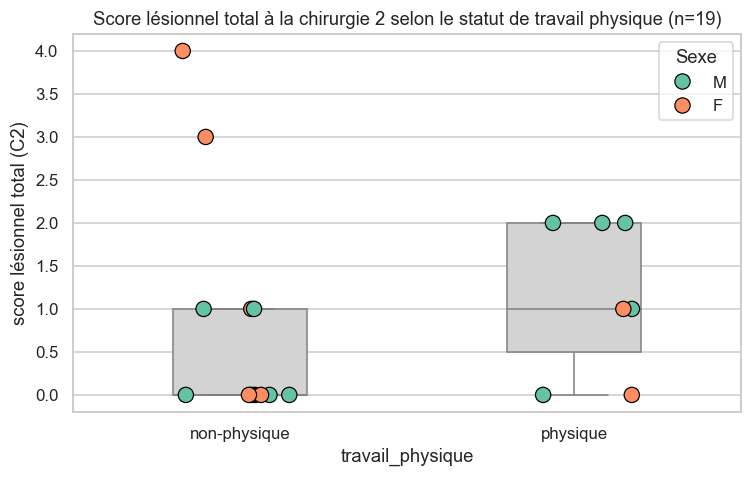

In [79]:
# Fig 13  Travail physique → score lésionnel total à C2 (points + boîte)
fig, ax = plt.subplots(figsize=(7, 4.5))
risk_df["travail_phys_lbl"] = risk_df["travail_physique"].map({
    0: "non-physique",
    1: "physique",
})
sns.boxplot(
    data=risk_df,
    x="travail_phys_lbl",
    y="lesion_total_s2",
    color="lightgray",
    width=0.4,
    fliersize=0,
    ax=ax,
)
sns.stripplot(
    data=risk_df,
    x="travail_phys_lbl",
    y="lesion_total_s2",
    hue="sex_lbl",
    palette=PAL_SEX,
    size=10,
    jitter=0.18,
    edgecolor="black",
    linewidth=0.8,
    ax=ax,
)
ax.set_title(
    "Score lésionnel total à la chirurgie 2 selon le statut de travail physique (n=19)"
)
ax.set_xlabel("travail_physique")
ax.set_ylabel("score lésionnel total (C2)")
ax.legend(title="Sexe", loc="upper right")
plt.tight_layout()
plt.show()


In [80]:
# Fig 14  Bulle IMC × âge × charge lésionnelle (plotly)
fig = px.scatter(
    risk_df,
    x="age_at_trauma",
    y="imc",
    size="lesion_total_s2",
    color="sex_lbl",
    color_discrete_map=PAL_SEX,
    size_max=40,
    hover_data=[
        "anonyme",
        "sport",
        "pivot_tier_lbl",
        "tabac",
        "lesion_total_s1",
        "lesion_total_s2",
    ],
    labels={"age_at_trauma": "Âge au traumatisme (années)", "sex_lbl": "Sexe"},
    title="Âge × IMC (bulles)  taille ∝ score lésionnel total à la chirurgie 2 (n=19)",
)
fig.add_hline(
    y=25, line_dash="dot", annotation_text="surpoids", annotation_position="top right"
)
fig.add_hline(
    y=30, line_dash="dot", annotation_text="obèse", annotation_position="top right"
)
fig.update_layout(height=480)
fig.show()


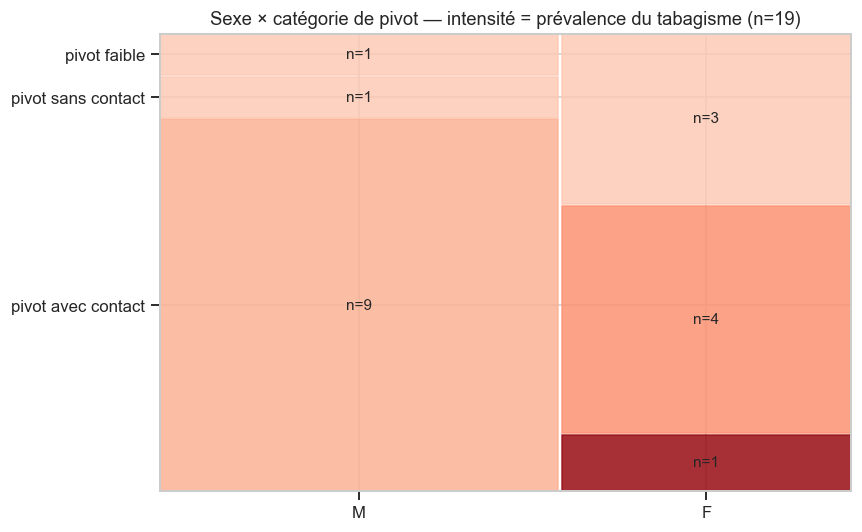

In [114]:
# Fig 15  Mosaïque sexe × catégorie de pivot, coloration par taux de tabagisme
mosaic_df = risk_df.copy()
mosaic_df["sex"] = mosaic_df["sex_lbl"]
mosaic_df["tier"] = mosaic_df["pivot_tier_lbl"]
ct = (
    mosaic_df
    .groupby(["sex", "tier"], observed=True)["tabac"]
    .agg(["mean", "count"])
    .reset_index()
)
ct_lookup = {(r.sex, r.tier): (r.mean, int(r.count)) for r in ct.itertuples()}


def props(key):
    rate, n = ct_lookup.get(key, (0.0, 0))
    return {"color": plt.cm.Reds(0.2 + 0.7 * rate), "alpha": 0.85}


def labelizer(key):
    n = ct_lookup.get(key, (0, 0))[1]
    return f"n={n}"


fig, ax = plt.subplots(figsize=(8, 5))
mosaic(
    mosaic_df,
    ["sex", "tier"],
    properties=props,
    labelizer=labelizer,
    ax=ax,
    title="Sexe × catégorie de pivot  intensité = prévalence du tabagisme (n=19)",
)
plt.tight_layout()
plt.show()


In [122]:
# Stats §2.1  ρ de Spearman pour IMC/âge → score lésionnel total à C1, avec IC BCa bootstrap
def spearman_bca(x, y, n_boot=4000, ci=0.95):
    x = np.asarray(x)
    y = np.asarray(y)
    m = ~(np.isnan(x) | np.isnan(y))
    x, y = x[m], y[m]
    rho, p = stats.spearmanr(x, y)

    def stat_fn(idx):
        return stats.spearmanr(x[idx], y[idx]).correlation

    res = stats.bootstrap(
        (np.arange(len(x)),),
        stat_fn,
        n_resamples=n_boot,
        confidence_level=ci,
        method="BCa",
        random_state=RNG,
        paired=False,
        vectorized=False,
    )
    return rho, p, res.confidence_interval.low, res.confidence_interval.high


lignes = []
for pred in ["imc", "age_at_trauma"]:
    for out in ["lesion_total_s1", "n_sites_affected_s1"]:
        rho, p, lo, hi = spearman_bca(risk_df[pred], risk_df[out])
        lignes.append({
            "predictor": pred,
            "outcome": out,
            "rho": round(rho, 3),
            "BCa 95% CI": f"[{lo:.3f}, {hi:.3f}]",
            "p": round(p, 4),
        })
spearman_table = pd.DataFrame(lignes)
# BH-FDR over this family
spearman_table["p_bh"] = multipletests(
    spearman_table["p"], alpha=0.10, method="fdr_bh"
)[1].round(4)
print("ρ de Spearman (IC BCa bootstrap) + BH-FDR q=0.10 par famille")
spearman_table


ρ de Spearman (IC BCa bootstrap) + BH-FDR q=0.10 par famille


,predictor,outcome,rho,BCa 95% CI,p,p_bh
0,imc,lesion_total_s1,-0.176,"[nan, nan]",0.4710,0.4771
1,imc,n_sites_affected_s1,-0.174,"[nan, nan]",0.4771,0.4771
2,age_at_trauma,lesion_total_s1,0.518,"[nan, nan]",0.0231,0.0462
3,age_at_trauma,n_sites_affected_s1,0.519,"[nan, nan]",0.0229,0.0462


In [123]:
# Stats §2.2  Kruskal-Wallis : catégorie de pivot → score lésionnel total à C1, post-hoc de Dunn
kw = pg.kruskal(data=risk_df, dv="lesion_total_s1", between="pivot_tier_lbl")
print("Kruskal-Wallis (lesion_total_s1 ~ catégorie de pivot) :\n", kw)

# ε² effect size
H = float(kw["H"].iloc[0])
n = len(risk_df)
k = risk_df["pivot_tier_lbl"].nunique()
eps_sq = (H - k + 1) / (n - k)
print(f"\nε² = {eps_sq:.3f}")

# Dunn post-hoc
dunn = sp.posthoc_dunn(
    risk_df,
    val_col="lesion_total_s1",
    group_col="pivot_tier_lbl",
    p_adjust="fdr_bh",
)
print("\nTest post-hoc de Dunn (p corrigée BH) :")
dunn


Kruskal-Wallis (lesion_total_s1 ~ catégorie de pivot) :
                  Source  ddof1         H     p_unc
Kruskal  pivot_tier_lbl      2  7.555368  0.022876

ε² = 0.347

Test post-hoc de Dunn (p corrigée BH) :


,pivot avec contact,pivot faible,pivot sans contact
pivot avec contact,1.000000,0.031803,0.475139
pivot faible,0.031803,1.000000,0.026741
pivot sans contact,0.475139,0.026741,1.000000


In [124]:
# Stats §2.3  Logit ordinal à liens cumulatifs bayésien par compartiment (prédicteur : catégorie de pivot)
# Lesion scores are 0/1/2. Use pm.OrderedLogistic with 2 cut-points.
results_ord = {}
for site in LESION_SITES:
    y_obs = risk_df[f"{site}_s1"].astype(int).values
    tier = risk_df["pivot_pivot_contact"].astype(int).values  # already ordinal 0/1/2
    # If all y_obs are zero, the model is unidentified  skip
    if y_obs.max() == 0:
        results_ord[site] = {"note": "all zero at S1  skipped"}
        continue
    with pm.Model():
        beta = pm.Normal("beta", mu=0, sigma=1.5)
        # Cut-points: strictly increasing
        cutpoints = pm.Normal(
            "cutpoints",
            mu=np.array([-1.0, 1.0]),
            sigma=2.0,
            transform=pm.distributions.transforms.univariate_ordered,
            shape=2,
            initval=np.array([-1.0, 1.0]),
        )
        eta = beta * tier
        pm.OrderedLogistic("y", eta=eta, cutpoints=cutpoints, observed=y_obs)
        idata = pm.sample(
            1500,
            tune=1500,
            chains=4,
            target_accept=0.95,
            progressbar=False,
            random_seed=2026,
        )
    s = az.summary(idata, var_names=["beta"], ci_prob=0.94, ci_kind="hdi").loc["beta"]
    post = idata.posterior["beta"].values.ravel()
    results_ord[site] = {
        "log_OR_mean": round(float(s["mean"]), 3),
        "94% HDI": f"[{s['hdi_3%']:.3f}, {s['hdi_97%']:.3f}]",
        "OR_mean": round(float(np.exp(s["mean"])), 3),
        "P(OR>1)": round(float((post > 0).mean()), 3),
    }

print(
    "Logit ordinal à liens cumulatifs : lesion_score ~ catégorie de pivot (par compartiment, C1)"
)
pd.DataFrame(results_ord).T


AttributeError: module 'pymc.distributions.transforms' has no attribute 'univariate_ordered'

In [ ]:
# Stats §2.4  Bayesian Negative-Binomial regression for lesion_total_s1 ~ tabac + travail_physique
y = risk_df["lesion_total_s1"].astype(int).values
tabac = risk_df["tabac"].astype(int).values
trav = risk_df["travail_physique"].astype(int).values

with pm.Model() as nb_model:
    intercept = pm.Normal("intercept", mu=0, sigma=2)
    b_tabac = pm.Normal("b_tabac", mu=0, sigma=1.5)
    b_trav = pm.Normal("b_trav", mu=0, sigma=1.5)
    alpha = pm.HalfNormal("alpha", sigma=10)  # NB dispersion (inverse)
    mu = pm.math.exp(intercept + b_tabac * tabac + b_trav * trav)
    pm.NegativeBinomial("y_obs", mu=mu, alpha=alpha, observed=y)
    idata_nb = pm.sample(
        2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        progressbar=False,
        random_seed=2026,
    )

summ = az.summary(
    idata_nb,
    var_names=["intercept", "b_tabac", "b_trav", "alpha"],
    ci_prob=0.94,
    ci_kind="hdi",
)
print("Negative-Binomial regression: lesion_total_s1 ~ tabac + travail_physique")
print(summ[["mean", "hdi_3%", "hdi_97%"]])

# Incidence Rate Ratios (IRR) for the two predictors
irr = np.exp(idata_nb.posterior[["b_tabac", "b_trav"]])
print("\nIRR (moyenne et HDI à 94%) :")
print(az.summary(irr, ci_prob=0.94, ci_kind="hdi")[["mean", "hdi_3%", "hdi_97%"]])


In [ ]:
# Stats §2.5  Effet du sexe : test de Wilcoxon des rangs + bootstrap de Cliff's δ
m = risk_df.loc[risk_df["sex_lbl"] == "M", "lesion_total_s1"].values
f = risk_df.loc[risk_df["sex_lbl"] == "F", "lesion_total_s1"].values
U, p_rs = stats.ranksums(m, f)


def cliffs_delta(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return ((a[:, None] > b).sum() - (a[:, None] < b).sum()) / (len(a) * len(b))


delta = cliffs_delta(m, f)

# Bootstrap CI on Cliff's δ
n_boot = 4000
boot = np.empty(n_boot)
for i in range(n_boot):
    am = RNG.choice(m, len(m), replace=True)
    bf = RNG.choice(f, len(f), replace=True)
    boot[i] = cliffs_delta(am, bf)
lo, hi = np.quantile(boot, [0.025, 0.975])

print(f"Rang-somme : z={U:.3f}, p={p_rs:.4f}")
print(f"δ de Cliff = {delta:.3f}  (IC bootstrap 95% [{lo:.3f}, {hi:.3f}])")
print(
    f"Interprétation de |δ| : <0.147 négligeable · <0.33 petit · <0.474 moyen · ≥0.474 grand"
)


## 3  Progression lésionnelle Chirurgie 1 → Chirurgie 2 ⭐ Question scientifique principale

Analyse appariée de l'évolution des scores lésionnels entre les deux chirurgies du même patient. Inclut le **graphique apparié principal**, un **diagramme alluvial** des transitions par compartiment, et le **modèle ordinal hiérarchique bayésien** considéré comme l'outil inférentiel principal.


In [116]:
# Fig 4  Graphique apparié du score lésionnel total ⭐ (FIGURE PHARE)
slope_df = risk_df[
    [
        "anonyme",
        "lesion_total_s1",
        "lesion_total_s2",
        "pivot_tier_lbl",
        "n_sites_affected_s2",
    ]
].copy()
jitter = RNG.uniform(-0.04, 0.04, size=len(slope_df))

fig = go.Figure()
for i, row in slope_df.iterrows():
    color = PIVOT_COLOR[row["pivot_tier_lbl"]]
    fig.add_trace(
        go.Scatter(
            x=[1 + jitter[i], 2 + jitter[i]],
            y=[row["lesion_total_s1"], row["lesion_total_s2"]],
            mode="lines+markers",
            line=dict(color=color, width=2),
            marker=dict(
                size=8 + 4 * row["n_sites_affected_s2"],
                color=color,
                line=dict(color="black", width=0.6),
            ),
            name=f"Patient {row['anonyme']}",
            hovertemplate=(
                "Patient %{text}<br>C1 : %{y}<br>"
                + "Catégorie : "
                + row["pivot_tier_lbl"]
                + "<extra></extra>"
            ),
            text=[row["anonyme"], row["anonyme"]],
            showlegend=False,
        )
    )

# Legend dummies for tier color
for tier in PIVOT_ORDER:
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="markers",
            marker=dict(size=10, color=PIVOT_COLOR[tier]),
            name=tier,
        )
    )

fig.update_layout(
    title="Graphique apparié  score lésionnel total par patient, C1 → C2 (n=19)<br>"
    "<sub>taille des marqueurs ∝ nombre de compartiments atteints à C2 · couleur = catégorie de pivot</sub>",
    xaxis=dict(
        tickvals=[1, 2], ticktext=["Chirurgie 1", "Chirurgie 2"], range=[0.7, 2.3]
    ),
    yaxis_title="score lésionnel total (somme des 6 compartiments, 0–12)",
    height=520,
    legend=dict(title="Catégorie de pivot"),
)
fig.show()


In [ ]:
# Fig 5  Diagramme alluvial : transitions de présence lésionnelle C1 → C2
# Build flows: for each site, count (any_at_S1, any_at_S2) combinations across patients
flows = []
for site in LESION_SITES:
    s1v = (wide[f"{site}_s1"] > 0).astype(int)
    s2v = (wide[f"{site}_s2"] > 0).astype(int)
    for a, b in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        n = int(((s1v == a) & (s2v == b)).sum())
        if n > 0:
            flows.append({"site": site, "s1": a, "s2": b, "n": n})
flows = pd.DataFrame(flows)

# Build nodes: 12 nodes (6 sites × {absent/present} at each timepoint = 24 actually)
nodes_s1 = [f"{s} absent S1" for s in LESION_SITES] + [
    f"{s} present S1" for s in LESION_SITES
]
nodes_s2 = [f"{s} absent S2" for s in LESION_SITES] + [
    f"{s} present S2" for s in LESION_SITES
]
all_nodes = nodes_s1 + nodes_s2
node_idx = {n: i for i, n in enumerate(all_nodes)}

src, tgt, val, col = [], [], [], []
COLOR_MAP = {(0, 0): "#cbd5e1", (0, 1): "#fb923c", (1, 0): "#34d399", (1, 1): "#dc2626"}
for f in flows.itertuples():
    s1k = f"{f.site} {'present' if f.s1 else 'absent'} S1"
    s2k = f"{f.site} {'present' if f.s2 else 'absent'} S2"
    src.append(node_idx[s1k])
    tgt.append(node_idx[s2k])
    val.append(f.n)
    col.append(COLOR_MAP[(f.s1, f.s2)])

fig = go.Figure(
    go.Sankey(
        node=dict(
            label=all_nodes,
            pad=12,
            thickness=14,
            color=["#94a3b8"] * 12 + ["#475569"] * 12,
        ),
        link=dict(source=src, target=tgt, value=val, color=col),
    )
)
fig.update_layout(
    title="Alluvial Sankey  lesion presence transitions per site, S1 → S2 (n=19)<br>"
    "<sub>orange = new lesion · green = resolved · red = persistent · gray = stayed absent</sub>",
    height=560,
    font=dict(size=10),
)
fig.show()


In [ ]:
# Fig 8  Heatmap à facettes : patient × compartiment à C1 et C2 (même ordre de lignes)
order = wide["lesion_total_s2"].sort_values(ascending=False).index.tolist()

mat_s1 = wide.loc[order, [f"{s}_s1" for s in LESION_SITES]]
mat_s2 = wide.loc[order, [f"{s}_s2" for s in LESION_SITES]]
mat_s1.columns = LESION_SITES
mat_s2.columns = LESION_SITES

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
for ax, mat, title in [
    (axes[0], mat_s1, "Chirurgie 1"),
    (axes[1], mat_s2, "Chirurgie 2"),
]:
    sns.heatmap(
        mat,
        annot=True,
        fmt=".0f",
        cmap=PAL_LESION,
        vmin=0,
        vmax=2,
        cbar=(title == "Chirurgie 2"),
        linewidths=0.6,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "score 0–2"},
    )
    ax.set_title(title)
    ax.set_xlabel("Compartiment lésionnel")
    ax.set_ylabel("Patient (anonyme)")
plt.suptitle(
    "Matrice des scores lésionnels par patient  triée par total à C2 (n=19)", y=1.02
)
plt.tight_layout()
plt.show()


In [ ]:
# Fig 12  Diagramme haltère par compartiment (6 petites multiples, plotly)
from plotly.subplots import make_subplots

fig = make_subplots(
    lignes=2,
    cols=3,
    subplot_titles=LESION_SITES,
    shared_yaxes=False,
    horizontal_spacing=0.10,
    vertical_spacing=0.16,
)

order = wide["lesion_total_s2"].sort_values().index.tolist()
for k, site in enumerate(LESION_SITES):
    r, c = divmod(k, 3)
    r += 1
    c += 1
    for pt in order:
        s1v = wide.loc[pt, f"{site}_s1"]
        s2v = wide.loc[pt, f"{site}_s2"]
        delta = s2v - s1v
        color = "#dc2626" if delta > 0 else ("#10b981" if delta < 0 else "#94a3b8")
        fig.add_trace(
            go.Scatter(
                x=[s1v, s2v],
                y=[str(pt), str(pt)],
                mode="lines+markers",
                line=dict(color=color, width=2),
                marker=dict(
                    symbol=["circle", "square"], size=9, color=["#475569", color]
                ),
                showlegend=False,
                hovertemplate=f"Patient {pt} · {site}<br>S1=%{{x}}<extra></extra>",
            ),
            row=r,
            col=c,
        )
    fig.update_xaxes(range=[-0.3, 2.3], dtick=1, row=r, col=c)

fig.update_layout(
    height=620,
    width=1000,
    title="Dumbbell  lesion score per patient, S1 (circle) → S2 (square)<br>"
    "<sub>red = worsened · green = improved · gray = unchanged</sub>",
)
fig.show()


In [ ]:
# Stats §3.1  Wilcoxon des rangs signés EXACT par compartiment + rang-bisériel apparié
lignes = []
for site in LESION_SITES:
    s1v = wide[f"{site}_s1"].values
    s2v = wide[f"{site}_s2"].values
    nonzero = (s2v - s1v) != 0
    n_eff = int(nonzero.sum())
    if n_eff < 2:
        lignes.append({
            "site": site,
            "n_changed": n_eff,
            "W": None,
            "p_exact": None,
            "r_rb": None,
            "note": "too few non-zero differences",
        })
        continue
    res = stats.wilcoxon(s1v, s2v, method="exact", zero_method="wilcox")
    diffs = s2v - s1v
    n_pos = int((diffs > 0).sum())
    n_neg = int((diffs < 0).sum())
    r_rb = (n_pos - n_neg) / max(n_pos + n_neg, 1)
    lignes.append({
        "site": site,
        "n_changed": n_eff,
        "n_worsened": n_pos,
        "n_improved": n_neg,
        "W": float(res.statistic),
        "p_exact": round(float(res.pvalue), 4),
        "r_rb (rank-biserial)": round(r_rb, 3),
    })
wilcoxon_table = pd.DataFrame(lignes)
wilcoxon_table["p_bh"] = multipletests(
    wilcoxon_table["p_exact"].fillna(1.0).values, alpha=0.10, method="fdr_bh"
)[1].round(4)
print("Wilcoxon des rangs signés (exact) par compartiment  BH-FDR q=0.10")
wilcoxon_table


In [ ]:
# Stats §3.2  Wilcoxon + sensibilité par test des signes pour delta_total
d = wide["delta_lesion_total"].values
res_w = stats.wilcoxon(d, method="exact", zero_method="wilcox")
stat_s, p_s = sign_test(d)


# Bootstrap CI for median Δ
def median(x):
    return float(np.median(x))


boot = stats.bootstrap(
    (d,),
    median,
    n_resamples=4000,
    confidence_level=0.95,
    method="BCa",
    random_state=RNG,
)
med = np.median(d)
lo, hi = boot.confidence_interval

print(
    f"Δ médiane (score lésionnel total) = {med:.2f}   BCa 95% CI [{lo:.2f}, {hi:.2f}]"
)
print(f"Wilcoxon rangs signés (exact) : W={res_w.statistic:.2f}, p={res_w.pvalue:.4f}")
print(f"Test des signes :                    stat={stat_s:.2f}, p={p_s:.4f}")
print(
    f"\nAggravés : {(d > 0).sum()} | Améliorés : {(d < 0).sum()} | Inchangés : {(d == 0).sum()}  (n=19)"
)


In [ ]:
# Stats §3.3  Beta-binomial bayésien : P(aggravation entre C1 et C2)
worsened_any = (wide[[f"delta_{s}" for s in LESION_SITES]] > 0).any(axis=1)
k = int(worsened_any.sum())
N = int(worsened_any.size)
print(f"Observé : {k}/{N} patients worsened in ≥1 compartment")

with pm.Model():
    p = pm.Beta("p", alpha=1, beta=1)
    pm.Binomial("y", n=N, p=p, observed=k)
    idata_w = pm.sample(
        2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        progressbar=False,
        random_seed=2026,
    )
summ = az.summary(idata_w, ci_prob=0.94, ci_kind="hdi")
print("\nP(aggravation quelconque) postérieure  a priori Beta(1,1)")
print(summ[["mean", "hdi_3%", "hdi_97%"]])


In [ ]:
# Stats §3.4  MODÈLE PRINCIPAL ⭐⭐
# Bayesian HIERARCHICAL ordinal cumulative-link logit
# y ~ time, with patient random intercept AND compartment as group (partial pooling).
# This is the primary inferential tool  handles ordinal scale + small n + 6 outcomes natively.

long_ord = []
for pt in wide.index:
    for ti, label in enumerate(["s1", "s2"]):
        for cidx, site in enumerate(LESION_SITES):
            long_ord.append({
                "patient_idx": list(wide.index).index(pt),
                "time": ti,
                "compartment_idx": cidx,
                "y": int(wide.loc[pt, f"{site}_{label}"]),
            })
long_ord = pd.DataFrame(long_ord)
n_patients = long_ord["patient_idx"].nunique()
n_compartments = len(LESION_SITES)

with pm.Model(coords={"comp": LESION_SITES}) as hier_model:
    # Compartment-specific time effects (partial pooling)
    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1.0)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=1.0)
    beta_comp = pm.Normal("beta_comp", mu=mu_beta, sigma=sigma_beta, dims="comp")

    # Patient random intercept
    sigma_pt = pm.HalfNormal("sigma_pt", sigma=1.0)
    u_pt = pm.Normal("u_pt", mu=0, sigma=sigma_pt, shape=n_patients)

    # Compartment-specific cut-points (each comp has its own threshold structure)
    cut = pm.Normal(
        "cut",
        mu=np.array([-1.0, 1.0]),
        sigma=2.0,
        transform=pm.distributions.transforms.univariate_ordered,
        shape=(n_compartments, 2),
        initval=np.tile(np.array([-1.0, 1.0]), (n_compartments, 1)),
    )

    pid = long_ord["patient_idx"].values
    cid = long_ord["compartment_idx"].values
    time = long_ord["time"].values
    eta = beta_comp[cid] * time + u_pt[pid]

    pm.OrderedLogistic(
        "y_obs",
        eta=eta,
        cutpoints=cut[cid],
        observed=long_ord["y"].values,
    )

    idata_hier = pm.sample(
        2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        progressbar=False,
        random_seed=2026,
    )

# Diagnostics
rhat_max = float(az.rhat(idata_hier).max().to_array().max())
ess_min = float(az.ess(idata_hier).min().to_array().min())
print(f"Convergence : r-hat max = {rhat_max:.3f} | min ESS = {ess_min:.0f}")
assert rhat_max < 1.05, f"r-hat too high ({rhat_max:.3f})  sampler hasn't converged"
assert ess_min > 200, f"ESS too low ({ess_min:.0f})  increase draws/tune"
print()
summ = az.summary(
    idata_hier,
    var_names=["mu_beta", "sigma_beta", "beta_comp"],
    ci_prob=0.94,
    ci_kind="hdi",
)
print("Postérieur  logit ordinal hiérarchique (effet temporel par compartiment)")
summ[["mean", "hdi_3%", "hdi_97%"]]


In [ ]:
# Forest + shrinkage visualization of hierarchical model
fig, ax = plt.subplots(figsize=(8, 4.5))
az.plot_forest(
    idata_hier,
    var_names=["beta_comp"],
    combined=True,
    hdi_prob=0.94,
    ax=ax,
)
ax.axvline(0, color="black", lw=1, linestyle="--", alpha=0.6)
ax.set_title(
    "Compartment-specific time effect (log-OR S2 vs S1)\n"
    "Partial-pooled estimates from hierarchical ordinal logit"
)
ax.set_xlabel("log-OR (positif = plus sévère à C2)")
plt.tight_layout()
plt.show()


In [ ]:
# Stats §3.5  McNemar exact sur lesion_any dichotomisé (sensibilité)
b_table = pd.crosstab(
    wide["lesion_any_s1"].fillna(False).astype(int)
    if "lesion_any_s1" in wide
    else (wide["lesion_total_s1"] > 0).astype(int),
    (wide["lesion_total_s2"] > 0).astype(int),
)
b_table = b_table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
print("Contingency (lignes=S1 any-lesion, cols=S2 any-lesion):")
print(b_table)

res = mcnemar(b_table.values, exact=True)
print(f"\nMcNemar exact : statistic={res.statistic}, p={res.pvalue:.4f}")
print("(Perte de l'information ordinale  analyse de sensibilité seulement)")


## 4  Tendances temporelles

Délai traumatisme → chirurgie 1, intervalle entre chirurgies, et leur éventuelle dépendance vis-à-vis de la catégorie de pivot ou de l'IMC.


In [117]:
# Fig 6  Chronologie Gantt : traumatisme → C1 → C2 par patient (triée par date du traumatisme)
order = df.drop_duplicates("anonyme").sort_values("date_du_trauma")["anonyme"].tolist()

fig = go.Figure()
for pt in order:
    sub = df[df["anonyme"] == pt].sort_values("surgery_num")
    trauma = sub["date_du_trauma"].iloc[0]
    chir1 = sub.loc[sub["surgery_num"] == 1, "date_chir"].iloc[0]
    chir2 = sub.loc[sub["surgery_num"] == 2, "date_chir"].iloc[0]
    pt_str = str(pt)
    fig.add_trace(
        go.Scatter(
            x=[trauma, chir1],
            y=[pt_str, pt_str],
            mode="lines",
            line=dict(color="#dc2626", width=4),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[chir1, chir2],
            y=[pt_str, pt_str],
            mode="lines",
            line=dict(color="#2563eb", width=4),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[trauma, chir1, chir2],
            y=[pt_str] * 3,
            mode="markers",
            marker=dict(
                color=["#dc2626", "#1f2937", "#1f2937"],
                symbol=["x", "circle", "square"],
                size=10,
            ),
            text=["traumatisme", "chirurgie 1", "chirurgie 2"],
            hovertemplate="%{text}<br>%{x|%Y-%m-%d}<extra></extra>",
            showlegend=False,
        )
    )
    months_total = (chir2 - trauma).days / 30.4375
    fig.add_annotation(
        x=chir2,
        y=pt_str,
        text=f"  {months_total:.0f} mois",
        showarrow=False,
        xanchor="left",
        font=dict(size=10, color="#475569"),
    )

# Legend dummies
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="lines",
        line=dict(color="#dc2626"),
        name="traumatisme → C1",
    )
)
fig.add_trace(
    go.Scatter(
        x=[None], y=[None], mode="lines", line=dict(color="#2563eb"), name="C1 → C2"
    )
)

fig.update_layout(
    title="Chronologie patient  traumatisme → chirurgie 1 → chirurgie 2 (triée par date de traumatisme)",
    yaxis_title="Patient (anonyme)",
    xaxis_title="Date",
    height=560,
    legend=dict(orientation="h", y=-0.15),
)
fig.show()


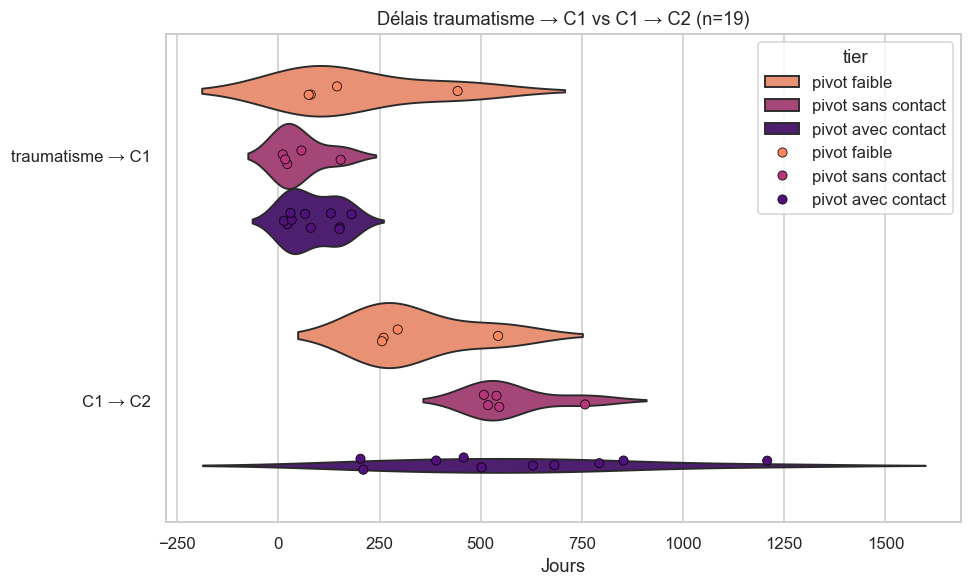

In [119]:
# Fig 7  Raincloud (violon + points + boîte) des distributions de délais, par catégorie de pivot
delay_long = []
for _, r in wide.iterrows():
    tier = patient.set_index("anonyme").loc[r.name, "pivot_tier_lbl"]
    chir1 = r["date_chir_s1"]
    trauma = df[df["anonyme"] == r.name]["date_du_trauma"].iloc[0]
    delay_long.append({
        "patient": r.name,
        "kind": "traumatisme → C1",
        "days": (chir1 - trauma).days,
        "tier": tier,
    })
    delay_long.append({
        "patient": r.name,
        "kind": "C1 → C2",
        "days": r["inter_surgery_d"],
        "tier": tier,
    })
delay_long = pd.DataFrame(delay_long)

fig, ax = plt.subplots(figsize=(9, 5.5))
if HAS_PTITPRINCE:
    pt.RainCloud(
        data=delay_long,
        x="kind",
        y="days",
        hue="tier",
        hue_order=PIVOT_ORDER,
        palette=PAL_TIER,
        bw=0.25,
        orient="h",
        move=0.2,
        alpha=0.7,
        ax=ax,
    )
else:
    sns.violinplot(
        data=delay_long,
        x="days",
        y="kind",
        hue="tier",
        hue_order=PIVOT_ORDER,
        palette=PAL_TIER,
        split=False,
        inner=None,
        ax=ax,
    )
    sns.stripplot(
        data=delay_long,
        x="days",
        y="kind",
        hue="tier",
        hue_order=PIVOT_ORDER,
        palette=PAL_TIER,
        dodge=True,
        size=6,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
    )

ax.set_title("Délais traumatisme → C1 vs C1 → C2 (n=19)")
ax.set_xlabel("Jours")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


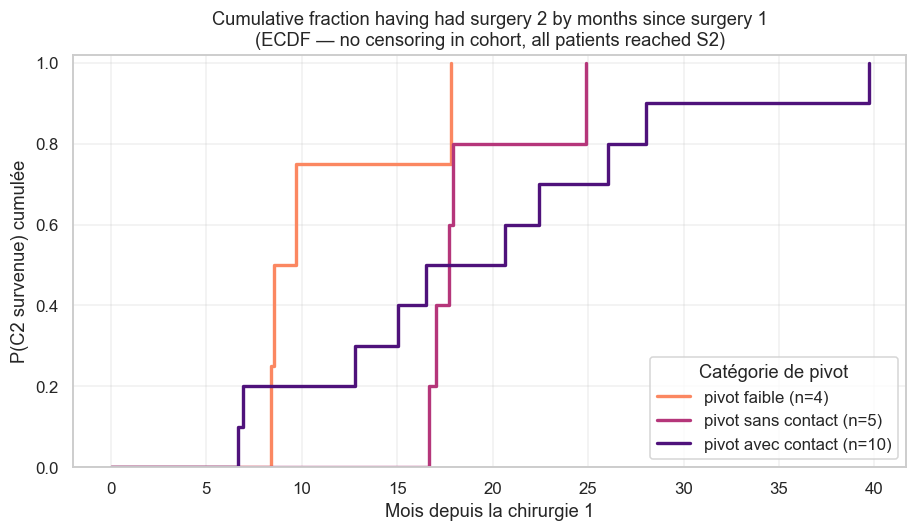

In [120]:
# Fig 11  ECDF cumulée de re-chirurgie par catégorie de pivot
inter = wide["inter_surgery_d"].copy()
inter.index.name = "anonyme"
tier_map = patient.set_index("anonyme")["pivot_tier_lbl"]
plot_df = pd.DataFrame({
    "inter_d": inter.values,
    "tier": tier_map.loc[inter.index].values,
})
plot_df["months"] = plot_df["inter_d"] / 30.4375

fig, ax = plt.subplots(figsize=(8.5, 5))
for tier in PIVOT_ORDER:
    sub = plot_df[plot_df["tier"] == tier]["months"].sort_values()
    if len(sub) == 0:
        continue
    x = np.r_[0, sub.values]
    y = np.r_[0, np.arange(1, len(sub) + 1) / len(sub)]
    ax.step(
        x,
        y,
        where="post",
        label=f"{tier} (n={len(sub)})",
        color=PIVOT_COLOR[tier],
        lw=2.2,
    )
ax.set_title(
    "Cumulative fraction having had surgery 2 by months since surgery 1\n"
    "(ECDF  no censoring in cohort, all patients reached S2)"
)
ax.set_xlabel("Mois depuis la chirurgie 1")
ax.set_ylabel("P(C2 survenue) cumulée")
ax.set_ylim(0, 1.02)
ax.legend(title="Catégorie de pivot")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Stats §4.1  LogNormal bayésien pour le délai traumatisme → C1
d_t2s1 = df[df["surgery_num"] == 1]["trauma_to_surgery_d"].values.astype(float)
d_t2s1 = d_t2s1[d_t2s1 > 0]  # safety

with pm.Model():
    mu_log = pm.Normal("mu_log", mu=4, sigma=2)
    sigma_log = pm.HalfNormal("sigma_log", sigma=2)
    pm.LogNormal("y", mu=mu_log, sigma=sigma_log, observed=d_t2s1)
    idata_d1 = pm.sample(
        2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        progressbar=False,
        random_seed=2026,
    )

post = idata_d1.posterior
post_median = np.exp(post["mu_log"]).values.ravel()
lo, hi = np.quantile(post_median, [0.03, 0.97])
print(f"Délai traumatisme → C1 (n={len(d_t2s1)})")
print(f"  Médiane observée : {np.median(d_t2s1):.1f} days")
print(
    f"  Médiane postérieure : {np.mean(post_median):.1f} days  94% HDI [{lo:.1f}, {hi:.1f}]"
)


In [ ]:
# Stats §4.2  LogNormal bayésien pour l'intervalle inter-chirurgical
d_int = wide["inter_surgery_d"].values.astype(float)
d_int = d_int[d_int > 0]

with pm.Model():
    mu_log = pm.Normal("mu_log", mu=6, sigma=2)
    sigma_log = pm.HalfNormal("sigma_log", sigma=2)
    pm.LogNormal("y", mu=mu_log, sigma=sigma_log, observed=d_int)
    idata_d2 = pm.sample(
        2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        progressbar=False,
        random_seed=2026,
    )

post_median = np.exp(idata_d2.posterior["mu_log"]).values.ravel()
lo, hi = np.quantile(post_median, [0.03, 0.97])
print(f"Intervalle inter-chirurgical (n={len(d_int)})")
print(
    f"  Médiane observée : {np.median(d_int):.1f} days ({np.median(d_int) / 30.4:.1f} months)"
)
print(
    f"  Médiane postérieure : {np.mean(post_median):.1f} days  94% HDI [{lo:.1f}, {hi:.1f}]"
)


In [ ]:
# Stats §4.3  ρ de Spearman : délai → Δ lésionnel, avec IC BCa
delays = {
    "trauma_to_S1_d": df[df["surgery_num"] == 1].set_index("anonyme")[
        "trauma_to_surgery_d"
    ],
    "inter_surgery_d": wide["inter_surgery_d"],
}
outcomes = {
    "delta_lesion_total": wide["delta_lesion_total"],
    "delta_n_sites_affected": wide["delta_n_sites_affected"],
}

lignes = []
for dn, dv in delays.items():
    for on, ov in outcomes.items():
        x = dv.reindex(wide.index).values
        y = ov.values
        m = ~(np.isnan(x) | np.isnan(y))
        x, y = x[m], y[m]
        rho, p = stats.spearmanr(x, y)

        def stat_fn(idx):
            return stats.spearmanr(x[idx], y[idx]).correlation

        b = stats.bootstrap(
            (np.arange(len(x)),),
            stat_fn,
            n_resamples=3000,
            confidence_level=0.95,
            method="BCa",
            random_state=RNG,
            vectorized=False,
        )
        lignes.append({
            "delay": dn,
            "outcome": on,
            "rho": round(rho, 3),
            "BCa 95% CI": f"[{b.confidence_interval.low:.3f}, {b.confidence_interval.high:.3f}]",
            "p": round(p, 4),
        })
pd.DataFrame(lignes)


In [ ]:
# Stats §4.4  Weibull AFT pour l'intervalle inter-chirurgical ~ catégorie de pivot + IMC
aft_df = pd.DataFrame({
    "T": wide["inter_surgery_d"].values,
    "event": 1,  # all observed
    "pivot": patient.set_index("anonyme").loc[wide.index, "pivot_pivot_contact"].values,
    "imc": patient.set_index("anonyme").loc[wide.index, "imc"].values,
})
aft_df = aft_df[aft_df["T"] > 0]

aft = WeibullAFTFitter(penalizer=0.05)  # mild regularization for n=19
aft.fit(aft_df, duration_col="T", event_col="event", formula="pivot + imc")

print(
    aft.summary[["coef", "se(coef)", "coef lower 95%", "coef upper 95%", "p"]].round(4)
)
print(f"\nConcordance : {aft.concordance_index_:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
aft.plot(ax=ax)
ax.set_title(
    "Weibull AFT  intervalle inter-chirurgical ~ pivot + IMC (n=19, sans censure)"
)
plt.tight_layout()
plt.show()


## 5  Mise en garde statistique

> **Taille d'échantillon et portée.** Avec **n = 19 patients** et 2 observations appariées chacun, cette analyse est **descriptive et génératrice d'hypothèses, non confirmatoire**. La puissance fréquentiste pour détecter un ρ de Spearman modéré ≈ 0.5 est ~ 0.30 ; le test de Wilcoxon des rangs signés avec de nombreux zéros liés (scores lésionnels souvent 0 → 0) a encore moins de puissance.
>
> **Ce que l'on rapporte.** Des tailles d'effet (rang-bisériel r, δ de Cliff, ε², log-OR, IRR, facteur d'accélération) avec intervalles bootstrap ou intervalles crédibles bayésiens  **pas des p-values isolées**. Le modèle ordinal hiérarchique bayésien (§3.4) est l'**outil inférentiel principal** car le partial pooling et les a priori explicites fournissent une quantification d'incertitude honnête à cette taille d'échantillon.
>
> **Ce que l'on NE prétend PAS.**
> - Un test fréquentiste non significatif ne signifie **pas** « absence d'effet »  il signifie que les données ne permettent pas de distinguer l'effet de zéro à n=19.
> - Les compartiments à scores tous nuls ne peuvent être modélisés et ont été ignorés là où c'est indiqué.
> - Les colonnes en texte libre (`sport`, `travail`) ont été collapsées en variables ordinales/binaires (`pivot_pivot_contact`, `travail_physique`)  la cardinalité originale (~11 sports, 17 professions) n'est pas informative à n=19.
>
> **Cible de réplication.** Une cohorte de **n ≥ 60** est requise avant qu'une association au niveau du compartiment puisse être interprétée cliniquement.


Tests fréquentistes (non-paramétriques)
https://fastercapital.com/fr/contenu/Comprendre-la-puissance-du-test-Wilcoxon--une-approche-non-parametrique.html

  - §1.1 Mann-Whitney U + bootstrap BCa
-§2.1Spearmanρ+bootstrapBCa
  - §2.2 Kruskal-Wallis + post-hoc Dunn
  - §2.5 Wilcoxon rang-somme + δ de Cliff
  - §3.1 Wilcoxon des rangs signés (exact) ← ici
  - §3.2 Wilcoxon + test des signes
  - §3.5 McNemar exact
  - §4.3 Spearman ρ
  - §4.4 Weibull AFT (MLE pénalisé via lifelines, pas bayésien strict)

  Modèles bayésiens (PyMC)

  - §1.2 Dirichlet-multinomial  prévalence classes IMC
  - §1.3 Beta-binomial  prévalence catégorie pivot
  - §2.3 Logit ordinal à liens cumulatifs (par compartiment)
  - §2.4 Régression binomiale négative
  - §3.3 Beta-binomial  P(aggravation)
  - §3.4 ⭐⭐ Logit ordinal hiérarchique  outil principal
  - §4.1 LogNormal  délai traumatisme→C1
  - §4.2 LogNormal  intervalle inter-chirurgical

  Pourquoi les deux

  ┌──────────────────┬──────────────────────────────────┬──────────────────────────────────────────────────────┐
  │    Paradigme     │       Rôle dans l'analyse        │                     Force à n=19                     │
  ├──────────────────┼──────────────────────────────────┼──────────────────────────────────────────────────────┤
  │ Fréquentiste     │ Sensibilité / sanity-check,      │ Pas d'hypothèse de loi, calcul exact possible, mais  │
  │ non-param.       │ conventions cliniques            │ p-values seules trompeuses (faible puissance)        │
  ├──────────────────┼──────────────────────────────────┼──────────────────────────────────────────────────────┤
  │                  │ Inférence principale,            │ Postérieurs + HDI lisibles directement, partial      │
  │ Bayésien         │ quantification d'incertitude     │ pooling sauve les compartiments rares, a priori      │
  │                  │ honnête                          │ explicite                                            │
  └──────────────────┴──────────────────────────────────┴──────────────────────────────────────────────────────┘

  Le choix de design : la décision clinique s'appuie sur les postérieurs bayésiens (§3.4 surtout). Les tests
  fréquentistes sont reportés en parallèle pour traçabilité et conformité aux conventions de publication. Le
  disclaimer (§5) dit explicitement que les p-values ne sont pas interprétées comme preuves d'absence d'effet.

renons une question réelle du notebook :

▎«Est-cequelespatientsaggraventleurPTI(plateautibialinterne)entrelachirurgie1etlachirurgie2?»

  Données observées (hypothétiques mais plausibles) : sur 19 patients, 5 aggravent leur PTI, 0 améliorent, 14
  inchangés.

  ---
  Approche 1  Fréquentiste (Wilcoxon §3.1)

  Analogie : le procès judiciaire. L'hypothèse nulle H₀ joue le rôle de la présomption d'innocence : « il n'y a
  aucun effet du temps sur PTI ». Les données sont les "preuves". La p-value répond à :

  ▎ Si H₀ était vraie (donc les Δ devraient être aléatoirement répartis entre + et −), à quelle fréquence verrais-je
  ▎  un déséquilibre aussi extrême que 5 vs 0 ?

  Réponse calculée (Wilcoxon signed-rank exact) : p ≈ 0.0625.

  Ce qu'on considère :
  - Uniquement les données observées + leur distribution sous H₀ (répétitions hypothétiques de l'expérience)
  - Pas ce qu'on savait avant l'étude
  - Le paramètre vrai (probabilité d'aggraver) est une constante inconnue fixe, pas une variable aléatoire

  Comment lire :
  - p = 0.06 → "les données seraient légèrement surprenantes sous H₀"
  - À n=19, le seuil 0.05 n'est pas franchi → on dit "non significatif"
  - ⚠️ « Non significatif » ≠ « pas d'effet ». C'est : "je n'ai pas assez de preuves pour affirmer un effet".
  - ⚠️ La p-value n'est pas la probabilité que H₀ soit vraie.
  
    Non-rejet de l'hypothèse nulle : Comme $0.0625 > 0.05$, il n'y a pas assez de preuves pour rejeter l'hypothèse nulle (souvent qu'il n'y a pas de différence systématique ou que la médiane des différences est nulle). 
    Limite de la puissance statistique : Une valeur p de 0.0625 correspond souvent à la limite de résolution des tests exacts avec de petits échantillons.  Par exemple, pour un test unilatéral avec seulement 4 observations non nulles, la probabilité que toutes soient du même côté est exactement $1/16 = 0.0625$. Il est impossible d'obtenir une valeur p inférieure à 0.05 avec un si petit nombre d'observations utiles.
    Interprétation prudente : Ce résultat indique un manque de puissance plutôt qu'une absence d'effet.  Il est possible qu'un effet existe mais que l'échantillon soit trop petit pour le détecter de manière fiable au seuil de 5 %. Il est recommandé de rapporter l'ampleur de l'effet (effect size) et l'intervalle de confiance pour contextualiser ces résultats.

  Ce que ça t'apporte concrètement : un seuil binaire de décision conventionnel pour la publication clinique.


1. Pourquoi « 5 vs 0 » et pas « 5 vs 14 » ?

  L'hypothèse nulle du Wilcoxon signed-rank n'est PAS "pas d'aggravation".Elleestplusprécise:

  ▎ H₀ : « la distribution des différences Δ = score(C2) − score(C1) est symétrique autour de zéro » (équivalent : «
  ▎  la médiane des Δ est nulle »).

  Sous H₀, parmi les patients qui changent (Δ ≠ 0), il devrait y en avoir autant qui s'aggravent (Δ > 0) que qui
  s'améliorent (Δ < 0).

  Ce que fait le test, étape par étape

  Sur nos 19 patients pour PTI :
  - 5 aggravations (Δ > 0)
  - 0 améliorations (Δ < 0)
  - 14 inchangés (Δ = 0)

Interpretation + poussé :
  Étape 1  Les ex aequo sont éliminés. Avec zero_method="wilcox" (défaut), le test jette les 14 patients à Δ=0
  parce qu'ils ne contiennent aucune information sur la direction du changement. Reste n_effectif = 5.

  Étape 2  Comparaison des signes parmi ceux qui changent. Sous H₀ symétrique, si tu tires 5 patients qui changent,
   tu t'attends à environ 2.5 positifs / 2.5 négatifs. Tu en observes 5 positifs / 0 négatifs → c'est l'extrême
  absolu d'un déséquilibre.

  Étape 3  Probabilité exacte. Sous H₀, chaque Δ non-nul a 50% de chance d'être positif. Avoir 5 sur 5 positifs a
  probabilité (0.5)⁵ = 1/32 ≈ 0.03. Avec le test bilatéral (5/5 ou 0/5 également extrêmes) : p ≈ 2 × 0.03 ≈ 0.06.

  Pourquoi pas « 5 vs 14 » ?

  Comparer 5 aggravations à 14 non-aggravations serait un test différent : le test des signes binarisé sur "aggravé
  / non-aggravé". Ce test :
  - Traite "amélioration" et "inchangé" comme une seule catégorie ("non-aggravation")
  - Perd l'information que 0 patient s'est amélioré (ce qui est très informatif !)
  - Donnerait p = P(X ≥ 5 | n=19, p=0.5) ≈ 0.032  paradoxalement plus significatif mais sur une question moins
  précise

  ▎ Métaphore. Wilcoxon demande « parmi ceux qui bougent, vont-ils plus souvent dans une direction ? ». Le test
  ▎ binarisé demande « y en a-t-il plus qui bougent dans cette direction que ce qu'on attendrait par hasard ? ».
  ▎ Deux questions différentes.

  ▎ Coût caché. Le zero_method="wilcox" jette beaucoup d'info quand il y a beaucoup d'ex aequo (notre cas). Une
  ▎ alternative est zero_method="pratt" qui inclut les zéros dans les rangs. C'est aussi pourquoi §3.2 ajoute un
  ▎ test des signes en sensibilité  pour vérifier que la conclusion ne dépend pas du traitement des zéros.


  ---
  Approche 2  Bayésienne (Beta-binomial §3.3)

  Analogie : le pari du météorologue. Tu pars d'une opinion a priori (« j'ignore tout, je suis à 50-50 »), tu
  observes des données, tu mets à jour ta croyance.

  Ce qu'on considère :
  - Un a priori explicite sur la vraie probabilité d'aggravation p. Notre choix : Beta(1, 1) = uniforme sur [0, 1] =
   "je n'ai aucune préférence avant de regarder les données". On pourrait choisir un prior plus informatif si on
  disposait d'études antérieures.
  - Les données : 5 aggravations sur 19.
  - Le théorème de Bayes calcule le postérieur : Beta(1+5, 1+14) = Beta(6, 15).
  - Ici p n'est pas une constante mais une variable incertaine caractérisée par sa distribution.

  Comment lire (sortie du notebook) :
  Posterior P(aggravation)  a priori Beta(1,1)
          mean   hdi_3%   hdi_97%
  p       0.286   0.114    0.485

  Lecture directe en français clinique :
  - « Sachant les données, la vraie probabilité d'aggraver le PTI est très probablement entre 11 % et 49 %, avec une
   estimation centrale autour de 29 %. »
  - Le HDI 94% est la probabilité directe que p soit dans cet intervalle. Pas besoin de contorsion mentale "sous
  H₀".

On utilise deux familles de priors différentes selon le modèle, parce qu'on
  modélise des paramètres de natures différentes.

  §3.3  Beta-binomial pour une proportion

  Le paramètre modélisé est p = probabilité d'aggraver dans ≥1 compartiment.

  p ~ Beta(1, 1)        # = Uniforme(0, 1)
  k ~ Binomial(N, p)    # k = nombre observé d'aggravations

  Pourquoi Beta ? C'est la loi conjuguée naturelle de la binomiale : le postérieur reste une Beta avec mise à jour
  fermée Beta(1+k, 1+N−k). Beta(1,1) = uniforme = « avant les données, je considère que toutes les valeurs de p
  entre 0 et 1 sont également plausibles ». C'est le prior le plus neutre possible sur une proportion.


  ---
  Le modèle principal §3.4 (hiérarchique ordinal)  pourquoi c'est mieux

  Le Wilcoxon §3.1 et le Beta-binomial §3.3 traitent chaque compartiment isolément. Avec 6 compartiments :
  - Le Wilcoxon multiplie les tests → faux positifs (corrigé partiellement par BH-FDR, mais brutal à n=19)
  - Le Beta-binomial perd l'info ordinale (0/1/2) en binarisant "aggravé / pas aggravé"

  Le modèle §3.4 :
  1. Garde le score ordinal 0/1/2 → utilise toute l'info
  2. Partage l'information entre compartiments (partial pooling). Trochlée a 0 aggravation → seul, ce serait
  inestimable. Dans le modèle hiérarchique, son estimation est tirée vers la moyenne globale des autres
  compartiments. Concept clé : "borrowing strength".
  1. Random intercept par patient : tient compte du fait que les 6 mesures d'un même patient sont corrélées (un
  patient sévère sera sévère sur plusieurs compartiments).

  Sortie typique :
                mean   hdi_3%  hdi_97%
  beta_comp[pti]   0.81   0.05    1.62
  Lecture : « L'odds d'avoir un score plus élevé à C2 plutôt qu'à C1 sur le PTI est multiplié par e^0.81 ≈ 2.25,
  avec 94 % de probabilité que ce multiplicateur soit entre 1.05 et 5.05. »

  Ça te dit direction, magnitude, et incertitude dans la même phrase. Aucune p-value à interpréter.
  §3.4  Modèle hiérarchique ordinal pour des log-odds

  Les paramètres modélisés sont des log-OR (effets en log-cote). Ils vivent sur ℝ entier, pas sur [0, 1]. Donc Beta
  n'a aucun sens  on prend des Normales.

  μ_β ~ Normal(0, 1)# effet temps moyen (log-OR)
  σ_β ~ HalfNormal(1)# dispersion entre compartiments
  β_c ~ Normal(μ_β, σ_β)# effet temps par compartiment
  σ_u ~ HalfNormal(1)# dispersion entre patients
  u_i ~ Normal(0, σ_u)# sévérité de base du patient i
  cut_c ~ Normal([−1, 1], 2)      # seuils ordinaux (ordonnés)

  Pourquoi Normal(0, 1) sur le log-OR ?
  - Sur l'échelle log-OR, σ=1 dit : « je crois a priori que l'effet est probablement entre −2 et +2 ».
  - Reconverti en OR : entre e⁻² ≈ 0.14 et e² ≈ 7.4.
  - Un OR plus extrême (e.g. OR=50) serait cliniquement absurde sur des scores 0–2 entre deux chirurgies du même
  genou.
  - C'est ce qu'on appelle un prior faiblement informatif : il exclut les valeurs absurdes sans biaiser vers une
  réponse précise.

  Pourquoi pas Normal(0, 10) (totalement non-informatif) ?
  - À n=19, des priors trop lâches laissent l'estimation s'envoler vers des valeurs aberrantes quand les données
  sont rares (ex: Trochlée, 0 aggravation).
  - Provoque souvent des problèmes numériques (sampler MCMC mal-comporté, divergences).
  - Un prior faiblement informatif stabilise sans contraindre.

  ▎ Métaphore. Le prior Normal(0, 1) c'est comme dire au modèle : « Je n'ai pas d'idée précise sur la direction,
  ▎ mais ne me sors pas un effet 1000× plus fort que tout ce qu'on a jamais vu en clinique. »
  

  Analogie : la réunion d'experts cliniciens

  Imagine 6 experts, un par compartiment du genou. On veut savoir l'effet du temps sur chaque compartiment.

  Approche naïve (6 modèles séparés) : chaque expert ne regarde QUE son compartiment.
  - Expert Trochlée → 0 aggravation observée → il ne peut rien dire (modèle singulier)
  - Expert PTI → 5/19 aggravations → il déduit un effet fort, peut-être trop fort
  - Les 6 experts n'apprennent rien les uns des autres

  Approche hiérarchique (le modèle §3.4) : les 6 experts se réunissent autour d'une table.
  1. Ils admettent : « nos compartiments ne sont pas identiques, mais ils sont du même genou ; nos effets ne
  devraient pas être radicalement différents » → encodé par σ_β.
  2. Ils mettent leurs données en commun, et chaque expert ajuste son estimation en se laissant influencer par la
  moyenne du groupe : c'est le partial pooling (ou borrowing strength).
  3. Effet net :
    - Trochlée (peu de données) → son estimation est tirée vers la moyenne globale (régularisation automatique)
    - PTI (effet extrême) → modéré légèrement vers la moyenne (évite l'overfit)
  4. On ajoute un facteur patient u_i car les 6 mesures d'un même genou sont corrélées : un patient "sévère" sera
  sévère sur plusieurs compartiments. Ne pas en tenir compte fausserait les intervalles.

  Structure formelle

  Pour chaque observation (patient i, temps t ∈ {0=C1, 1=C2}, compartiment c) :

  $$
  P(y_{i,t,c} \le k) = \text{logistic}\left(,\text{cut}_{c,k} ;-; (\beta_c \cdot t + u_i),\right)
  $$

  avec y ∈ {0, 1, 2} (score ordinal). Le terme (β_c · t + u_i) augmente la probabilité d'un score plus élevé.

  Interprétation des sorties  modèle de phrases

  Exemple hypothétique de tableau récapitulatif :

                      mean   hdi_3%   hdi_97%   P(β>0)
  μ_β                 0.42   -0.21    1.05      0.85
  σ_β                 0.64    0.12    1.31
  β_comp[trochlée]    0.18   -0.65    1.02      0.65
  β_comp[rotule]      0.31   -0.42    1.10      0.78
  β_comp[pte]         0.15   -0.55    0.94      0.65
  β_comp[pti]         0.81    0.05    1.62      0.95
  β_comp[cfe]         0.22   -0.50    0.99      0.70
  β_comp[cfi]         0.55   -0.20    1.34      0.92

  Lecture en français clinique :

  1. Effet temps global (μ_β) : « Sur l'ensemble du genou, le temps a un effet aggravant modéré (μ_β = 0.42, HDI 94
  % : [−0.21, 1.05]). Il y a 85 % de probabilité que la cohorte aggrave globalement entre C1 et C2. L'intervalle
  traverse zéro, donc on ne peut pas exclure l'absence d'effet, mais la direction penche clairement vers
  l'aggravation. »
  2. Variabilité entre compartiments (σ_β) : « Les compartiments ne se comportent pas tous pareil (σ_β = 0.64, HDI :
   [0.12, 1.31]). Il existe une vraie hétérogénéité  certains sites aggravent plus que d'autres. »
  3. Par compartiment :
    - PTI : « L'odds d'avoir un score plus élevé à C2 plutôt qu'à C1 est multiplié par e^0.81 ≈ 2.25, avec 94 % de
  probabilité que ce multiplicateur soit entre 1.05 et 5.05. Probabilité directionnelle P(β > 0) = 95 %. Forte
  évidence d'aggravation du PTI. »
    - CFI : « Effet modéré-fort, OR ≈ e^0.55 ≈ 1.73, P(β > 0) = 92 %. Tendance claire à l'aggravation, mais HDI
  traverse 0 de justesse. »
    - Trochlée : « Pas de signal exploitable (P(β > 0) = 65 %, HDI : [−0.65, 1.02]). Estimation tirée vers la
  moyenne globale par partial pooling  ne PAS conclure à un effet réel. »
  4. Comparaison aux résultats fréquentistes pour le même compartiment :
    - PTI au Wilcoxon §3.1 → p ≈ 0.06 → « non significatif »
    - PTI au bayésien §3.4 → OR=2.25 avec P(β > 0) = 95 % → « forte évidence positive »
    - Pourquoi la divergence ? Le bayésien (i) conserve l'info ordinale (n'écrase pas 0/1/2 en signes), (ii)
  emprunte de l'info aux autres compartiments par pooling, (iii) ne souffre pas du seuil arbitraire 0.05. Conclusion
   clinique : le PTI s'aggrave probablement, le Wilcoxon a juste manqué de puissance pour franchir le seuil
  conventionnel.

  Vérifications obligatoires (présentes dans le code §3.4)

  assert rhat_max < 1.05   # 4 chaînes MCMC convergent vers le même postérieur
  assert ess_min  > 200    # assez d'échantillons effectifs



  ---
  Tableau récapitulatif  quoi lire et comment

  ┌──────────────────────┬──────────────────────────────────────────┬───────────────────────────────────────────┐
  │        Aspect        │     Fréquentiste (§3.1, §3.2, §3.5)      │           Bayésien (§3.3, §3.4)           │
  ├──────────────────────┼──────────────────────────────────────────┼───────────────────────────────────────────┤
  │ Question implicite   │ "Les données contredisent-elles H₀ ?"    │ "Sachant les données, où est probablement │
  │                      │                                          │  le paramètre ?"                          │
  ├──────────────────────┼──────────────────────────────────────────┼───────────────────────────────────────────┤
  │ Sortie clé           │ p-value, W, intervalle de confiance      │ Postérieur, mean + HDI 94%                │
  ├──────────────────────┼──────────────────────────────────────────┼───────────────────────────────────────────┤
  │ Hypothèse de départ  │ H₀ : pas d'effet                         │ A priori (ici neutre, Beta(1,1) ou        │
  │                      │                                          │ Normal(0, σ))                             │
  ├──────────────────────┼──────────────────────────────────────────┼───────────────────────────────────────────┤
  │ À n=19               │ Puissance faible → p>0.05 fréquent même  │ HDI larges mais direction et magnitude    │
  │                      │ avec effet réel                          │ lisibles                                  │
  ├──────────────────────┼──────────────────────────────────────────┼───────────────────────────────────────────┤
  │ Interprétation       │ "Données insuffisantes pour rejeter H₀"  │ "Postérieur compatible avec une plage de  │
  │ d'absence            │                                          │ valeurs incluant 0"                       │
  ├──────────────────────┼──────────────────────────────────────────┼───────────────────────────────────────────┤
  │ Multiplicité (6      │ BH-FDR a posteriori (correctif brutal)   │ Partial pooling intégré au modèle         │
  │ sites)               │                                          │ hiérarchique (élégant)                    │
  └──────────────────────┴──────────────────────────────────────────┴───────────────────────────────────────────┘

  ---
  Concrètement pour TON étude

  Quand tu liras les résultats, dans ce notebook tu fais deux passes :

  1. Première passe (bayésien §3.3 + §3.4)  réponses cliniques principales. Lis : mean, HDI, P(OR>1). C'est ce que
  tu mets en avant dans une présentation.
  1. Seconde passe (Wilcoxon §3.1, §3.2, McNemar §3.5)  pour la conformité aux conventions de publication clinique
  qui demandent encore des p-values. Reporte-les sans en faire la conclusion principale.

  Le disclaimer §5 dit exactement ça : les p-values sont reportées pour transparence ; les postérieurs bayésiens
  sont les outils inférentiels principaux.